### MMSegmentation (OpenMMLab): 这是一个非常强大的开源语义分割库。你可以直接使用它提供的 Unet、DeepLab 等模型，只需修改配置文件适配你的遥感数据集。
### pytorch 学习 
### Albumentations: 强大的数据增强库，专门处理图像分割任务的增强（旋转、翻转、色彩抖动）。

In [3]:
import torch
x = torch.rand(5, 3)
print(x)

tensor([[0.0313, 0.5134, 0.8187],
        [0.4615, 0.4433, 0.7384],
        [0.1562, 0.5224, 0.6681],
        [0.1308, 0.2966, 0.2708],
        [0.7269, 0.9843, 0.3975]])


In [4]:
import torch
torch.cuda.is_available()

True

In [5]:
import torch.nn as nn

In [6]:
import torch.nn as nn
import torch
import torch.nn.functional as F
class simpleCNN(nn.Module):
    def __init__(self):
        super(simpleCNN, self).__init__()
        # 第一个卷积层 输入通道数为1，输出通道数为32，卷积核大小为3x3，步长为1
        self.conv1 = nn.Conv2d(1, 32, 3,1)
        # 第二个卷积层 输入通道数为32，输出通道数为64，卷积核大小为3x3,步长为1
        self.conv2 = nn.Conv2d(32, 64, 3,1)
        # 最大池化层，池化窗口大小为2x2
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # DropOut层1，丢弃概率为0.25
        self.dropout1 = nn.Dropout2d(0.25)
        # DropOut层2，丢弃概率为0.5
        self.dropout2 = nn.Dropout(0.5)   
        # 全连接层 输入特征数为64*5*5，输出特征数为128
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        # 输出层 输入特征数为128，输出特征数为10（假设有10个类别）
        self.fc2 = nn.Linear(128, 10)

    # 前向传播函数，定义了数据如何通过网络进行传播
    def forward(self, x):
        x=self.conv1(x)  # 通过第一个卷积层
        x=F.relu(x)   # 通过ReLU激活函数
        x=self.pool(x)   # 通过池化层
        x=self.conv2(x)  # 通过第二个卷积层
        x=F.relu(x)   # 通过ReLU激活函数
        x=self.pool(x)   # 通过池化层
        x=self.dropout1(x)  # 通过第一个DropOut层

        # 将特征图展平为一维向量，以便输入到全连接层
        x = torch.flatten(x, 1)  # 从第1维开始展平，保留批次维度
        x=self.fc1(x)    # 通过第一个全连接层
        x=F.relu(x)   # 通过ReLU激活函数
        x=self.dropout2(x)  # 通过第二个DropOut层

        # 通过输出层，得到最终的分类结果
        x=self.fc2(x)
        return x
    

# 将模型移动到GPU（如果可用）
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model=simpleCNN().to(device)

In [7]:
# 定义数据预处理：转换为张量并标准化
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST数据集的全局均值和标准差
])

# 加载训练集和测试集
train_dataset = datasets.MNIST('D:\\pyLearn\\test_project\\data', train=True, download=False, transform=transform)
test_dataset = datasets.MNIST('D:\\pyLearn\\test_project\\data', train=False, download=False, transform=transform)
# 训练集文件命名格式为"train-xxxxxx.pt"，测试集文件命名格式为"test-xxxxxx.pt"

# 创建数据加载器
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# 确认加载成功
print(f"训练集大小: {len(train_dataset)}")  # 应该输出 60000
print(f"测试集大小: {len(test_dataset)}")    # 应该输出 10000
print(f"图像形状: {train_dataset[0][0].shape}")  # 应该输出 torch.Size([1, 28, 28])
print(f"标签范围: {min(train_dataset[i][1] for i in range(100))} - {max(train_dataset[i][1] for i in range(100))}")  # 应该输出 0 - 9

训练集大小: 60000
测试集大小: 10000
图像形状: torch.Size([1, 28, 28])
标签范围: 0 - 9


Batch 图像形状: torch.Size([64, 1, 28, 28])
Batch 标签: tensor([3, 3, 7, 3, 5, 7, 0, 5, 5, 5])


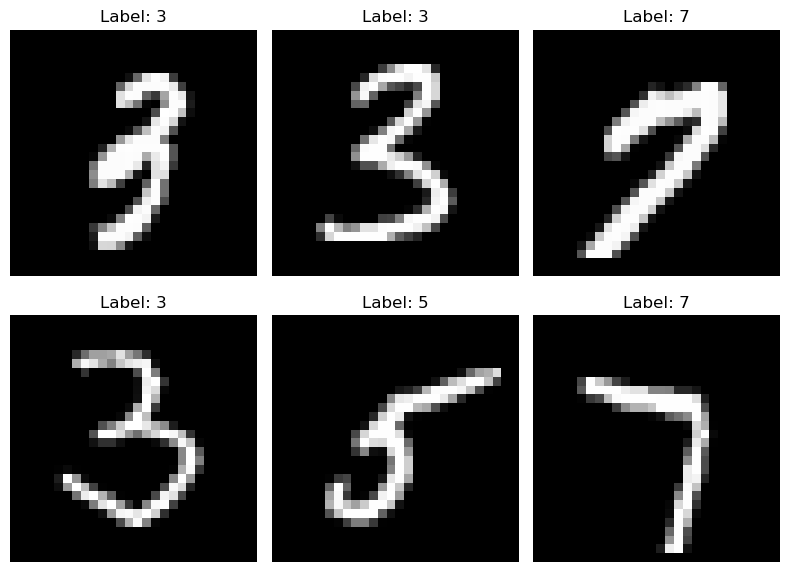

In [8]:
import matplotlib.pyplot as plt
import torchvision
import torch

# 创建数据加载器
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# 获取一个batch的数据
# 获取一个batch的数据，images是图像张量，labels是对应的标签，
# iter(train_loader)创建一个迭代器，next()获取下一个batch的数据,当前获取的是第一个batch的数据，
# 迭代器是从0开始的，所以第一次调用next()会获取第一个batch的数据，第二次调用会获取第二个batch的数据，以此类推。
images, labels = next(iter(train_loader)) 
print(f"Batch 图像形状: {images.shape}")  # 应该是 [64, 1, 28, 28]
print(f"Batch 标签: {labels[:10]}")  # 打印前10个标签

# 显示前6张图片
fig, axes = plt.subplots(2, 3, figsize=(8, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray') # squeeze()函数用于去掉图像张量中的单通道维度，使其变为二维数组，便于显示
    ax.set_title(f'Label: {labels[i].item()}') # item()函数用于获取标签的数值，方便显示，不使用则数据类型为tensor对象
    ax.axis('off')
plt.tight_layout()
plt.show()

In [9]:
# 定义损失函数和优化器

# 交叉熵损失函数，适用于多分类问题
criterion = nn.CrossEntropyLoss()
# 使用Adam优化器
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [20]:
from datetime import datetime

from torch.utils.tensorboard import SummaryWriter
# 生成唯一的日志目录名，包含时间戳
log_dir = "runs/experiment_{}".format(datetime.now().strftime("%Y-%m-%d_%H-%M-%S"))
# 初始化 Writer 指向新目录
writer = SummaryWriter(log_dir=log_dir)

# 训练与评估函数
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward() # 反向传播计算梯度
        optimizer.step() # 更新模型参数
        if batch_idx % 100 == 0:
            # 打印训练进度和损失值，在batch_idx达到100的倍数时输出一次，一个batch包含64个样本，所以每训练6400个样本输出一次
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')
            writer.add_scalar('Loss/Train', loss.item(), epoch * len(train_loader) + batch_idx)

def test(model, device, test_loader, criterion):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True) # 获取预测结果的索引，即预测的类别
            correct += pred.eq(target.view_as(pred)).sum().item() # 计算预测正确的数量，pred.eq(target.view_as(pred))比较预测结果和真实标签是否相等，返回一个布尔张量，sum()统计True的数量，item()获取数值

    test_loss /= len(test_loader)
    accuracy = 100. * correct / len(test_loader.dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)\n')
    writer.add_scalar('Loss/Test', test_loss, epoch)
    writer.add_scalar('Accuracy/Test', accuracy, epoch)


# 开始训练
for epoch in range(1, 6):  # 训练5个epoch
    
    train(model, device, train_loader, optimizer, criterion, epoch)
    test(model, device, test_loader, criterion)

Train Epoch: 1 [0/60000 (0%)]	Loss: 0.011110
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.000821
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.126587
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.000301
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.049746
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.000962
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.010399
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.000748
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.078282
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.020380

Test set: Average loss: 0.0237, Accuracy: 9939/10000 (99.39%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.012892
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.004162
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.001880
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.027271
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.002289
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.005153
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.000009
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.000210
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.00055